<div style="text-align: center; font-family: Arial; line-height: 1.5;">

# Instituto Internacional de Aguascalientes

## Maestría en Inteligencia Artificial para la Transformación Digital

### Programa: Aprendizaje Inteligente

<br><br>

## Práctica: análisis, implementación y evaluación comparativa de KNN y CART aplicado al diagnóstico predictivo de cáncer de próstata mediante curva ROC

<br><br>

**Alumno:** Antonio Nicolás Toro González  
**Tutor:** Dr. Francisco Javier Luna Rosas

<br><br><br>

## Julio 2026

</div>


<style>
/* Estilo académico uniforme para notebook, HTML y PDF impreso */
.jp-RenderedHTMLCommon,
.jp-MarkdownOutput,
.rendered_html {
    font-family: Arial, Helvetica, sans-serif !important;
    font-size: 12pt !important;
    line-height: 1.5 !important;
}

/* Portada y títulos: diferencia moderada, sin saltos bruscos */
.jp-RenderedHTMLCommon h1,
.jp-MarkdownOutput h1,
.rendered_html h1 {
    font-family: Arial, Helvetica, sans-serif !important;
    font-size: 18pt !important;
    line-height: 1.35 !important;
    font-weight: 700 !important;
}

.jp-RenderedHTMLCommon h2,
.jp-MarkdownOutput h2,
.rendered_html h2 {
    font-family: Arial, Helvetica, sans-serif !important;
    font-size: 16pt !important;
    line-height: 1.35 !important;
    font-weight: 700 !important;
}

.jp-RenderedHTMLCommon h3,
.jp-MarkdownOutput h3,
.rendered_html h3 {
    font-family: Arial, Helvetica, sans-serif !important;
    font-size: 14pt !important;
    line-height: 1.35 !important;
    font-weight: 700 !important;
}

.jp-RenderedHTMLCommon h4,
.jp-MarkdownOutput h4,
.rendered_html h4 {
    font-family: Arial, Helvetica, sans-serif !important;
    font-size: 12.5pt !important;
    line-height: 1.35 !important;
    font-weight: 700 !important;
}

.jp-RenderedHTMLCommon p,
.jp-MarkdownOutput p,
.rendered_html p,
.jp-RenderedHTMLCommon li,
.jp-MarkdownOutput li,
.rendered_html li {
    font-family: Arial, Helvetica, sans-serif !important;
    font-size: 12pt !important;
    line-height: 1.5 !important;
    text-align: justify;
}

/* Tablas con tamaño cercano al texto normal */
.jp-RenderedHTMLCommon table,
.jp-MarkdownOutput table,
.rendered_html table {
    font-family: Arial, Helvetica, sans-serif !important;
    font-size: 11pt !important;
}

.jp-RenderedHTMLCommon th,
.jp-MarkdownOutput th,
.rendered_html th,
.jp-RenderedHTMLCommon td,
.jp-MarkdownOutput td,
.rendered_html td {
    font-family: Arial, Helvetica, sans-serif !important;
    font-size: 11pt !important;
    line-height: 1.35 !important;
}

/* Código: se conserva monoespaciado, pero se evita que domine visualmente */
.jp-CodeCell,
.jp-InputArea,
.jp-OutputArea,
pre,
code {
    font-size: 10.5pt !important;
    line-height: 1.35 !important;
}
</style>


## Repositorios y URL

**Repositorio GitHub:**  
https://github.com/antoniot73/ml_knn_cart_cancer_prostata

**URL Binder:**  
https://mybinder.org/v2/gh/antoniot73/ml_knn_cart_cancer_prostata/main?filepath=practica_knn_cart_prostata.ipynb

**GitHub Page:**  
https://antoniot73.github.io/ml_knn_cart_cancer_prostata/practica_knn_cart_prostata.html

**Dataset original:**  
https://www.kaggle.com/datasets/sajidsaifi/prostate-cancer


## 1. Marco teórico y analítico

### 1.1 Aprendizaje supervisado y clasificación binaria

El aprendizaje supervisado permite construir modelos predictivos a partir de datos previamente etiquetados. En un problema de clasificación, se dispone de una base de datos $D = \{t_1, t_2, ..., t_n\}$ formada por registros o individuos, y de un conjunto de clases $C = \{C_1, C_2, ..., C_m\}$. El objetivo es encontrar una función:

$$
f:D \rightarrow C
$$

capaz de asignar cada registro $t_i$ a una clase $C_j$.

En esta práctica, el problema se formula como una clasificación binaria aplicada al diagnóstico predictivo de cáncer de próstata. Cada registro representa una observación con variables morfológicas y la clase objetivo indica si el diagnóstico corresponde a una condición benigna o maligna.


### 1.2 Dataset de cáncer de próstata

Se utiliza el **Prostate Cancer Dataset**, disponible en Kaggle:

https://www.kaggle.com/datasets/sajidsaifi/prostate-cancer

El conjunto de datos contiene mediciones morfológicas asociadas a muestras de cáncer de próstata. Su utilidad para esta práctica radica en que combina variables numéricas continuas con una variable objetivo binaria, lo que permite evaluar algoritmos de clasificación supervisada bajo un mismo marco experimental.

La variable objetivo es:

- `diagnosis_result`: diagnóstico binario.
  - `M`: maligno.
  - `B`: benigno.

Las variables predictoras consideradas son:

- `radius`
- `texture`
- `perimeter`
- `area`
- `smoothness`
- `compactness`
- `symmetry`
- `fractal_dimension`

El aporte principal del dataset es que permite comparar dos enfoques distintos de clasificación: uno basado en cercanía entre observaciones (**KNN**) y otro basado en reglas jerárquicas de decisión (**CART**).


### 1.3 Modelo K-Nearest Neighbors (KNN)

KNN es un algoritmo supervisado, no paramétrico y basado en instancias. No construye un modelo explícito durante el entrenamiento; almacena los registros y clasifica nuevas observaciones según la clase predominante entre sus vecinos más cercanos.

En esta práctica, KNN es pertinente porque las variables del dataset son numéricas continuas. Por ello, el algoritmo puede medir distancias entre observaciones y analizar si los casos benignos y malignos se agrupan en regiones diferenciables del espacio de características.

Su principal requerimiento técnico es la estandarización de variables, ya que las distancias pueden verse dominadas por atributos con escalas mayores, como `area` o `perimeter`.


### 1.4 Modelo CART: Árbol de Decisión

CART (*Classification and Regression Trees*) construye reglas de decisión jerárquicas mediante particiones sucesivas del espacio de variables. En clasificación, busca divisiones que aumenten la pureza de los nodos, comúnmente mediante el índice de Gini.

En esta práctica, CART resulta útil porque genera un modelo interpretable y permite observar qué variables morfológicas tienen mayor peso en la clasificación. Además, su salida probabilística permite construir la curva ROC y comparar su desempeño contra KNN.


### 1.5 Justificación de los modelos seleccionados

Se seleccionan **KNN** y **CART** porque representan dos enfoques diferentes de clasificación supervisada:

- **KNN** clasifica por similitud geométrica entre registros.
- **CART** clasifica mediante reglas jerárquicas interpretables.

Esta diferencia permite comparar si el dataset se explica mejor mediante vecindad entre observaciones o mediante reglas de partición. No se selecciona Naive Bayes porque asume independencia condicional entre predictores, y en este dataset varias variables morfológicas, como `radius`, `perimeter` y `area`, pueden presentar correlación natural.


### 1.6 Curva ROC y AUC

La curva ROC (*Receiver Operating Characteristic*) permite evaluar clasificadores binarios considerando diferentes umbrales de decisión. La curva compara:

- **TPR o sensibilidad:** proporción de casos positivos correctamente identificados.
- **FPR:** proporción de casos negativos clasificados erróneamente como positivos.

El área bajo la curva (**AUC**) resume la capacidad discriminativa del modelo. Un AUC (Area Under the Curve) cercano a 1 indica mejor separación entre clases, mientras que un AUC cercano a 0.5 indica comportamiento similar al azar.


## 2. Motivación de la práctica

Esta práctica busca analizar, implementar y evaluar dos máquinas de aprendizaje supervisado sobre un mismo problema de clasificación médica. El objetivo no es automatizar un diagnóstico clínico real, sino comprender cómo KNN y CART aprenden patrones desde un dataset tabular y cómo pueden compararse mediante la curva ROC.

El uso de un dataset de cáncer de próstata permite conectar el aprendizaje supervisado con un caso aplicado de clasificación binaria, reforzando la interpretación de métricas como sensibilidad, falsos positivos y AUC.


## 3. Planteamiento del problema

Cada registro del dataset representa una observación descrita por variables morfológicas. El problema consiste en clasificar cada registro como benigno o maligno.

Formalmente:

$$
D = \{t_1, t_2, ..., t_n\}
$$

donde cada $t_i$ contiene variables predictoras numéricas, y:

$$
C = \{B, M\}
$$

donde:

- `B`: benigno.
- `M`: maligno.

La función de clasificación será aproximada mediante dos modelos:

$$
f_{KNN}:D \rightarrow C
$$

$$
f_{CART}:D \rightarrow C
$$

Ambos modelos se evaluarán con la misma partición de datos y se compararán mediante métricas de clasificación y curva ROC.


## 4. Implementación en Python

La implementación se realiza en Python utilizando una estructura modular dentro del notebook. Se conserva el estilo de la práctica de referencia: carga del dataset, despliegue en ventana HTML con scroll, validación, entrenamiento, evaluación y generación de gráficas.


### Paquetes de Python utilizados

| Paquete | Uso en la práctica |
|---|---|
| `pathlib` | Gestión de rutas del proyecto. |
| `logging` | Registro de eventos del pipeline. |
| `numpy` | Operaciones numéricas. |
| `pandas` | Carga, validación y manipulación del dataset. |
| `matplotlib` | Generación de gráficas. |
| `IPython.display` | Visualización HTML del dataset con scroll. |
| `sklearn.model_selection` | División entrenamiento/prueba. |
| `sklearn.preprocessing` | Codificación de clases y escalamiento. |
| `sklearn.neighbors` | Implementación de KNN. |
| `sklearn.tree` | Implementación de CART. |
| `sklearn.metrics` | Métricas, matrices de confusión, ROC y AUC. |


### Documentación técnica mediante docstrings

El notebook incluye funciones documentadas mediante docstrings. Cada docstring explica el propósito de la función, sus entradas, salidas, validaciones, excepciones y su papel dentro del pipeline. Esto permite que la práctica sea reproducible, verificable y mantenible.


In [1]:
# Configuración general del proyecto, rutas, dependencias y logging.

from pathlib import Path
import logging
import sys
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import HTML, display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
)

def find_project_root(start_path: Path) -> Path:
    """Localiza la raíz del proyecto buscando la carpeta data.

    Esta función permite ejecutar el notebook desde distintas ubicaciones
    sin depender de rutas absolutas. Recorre la ruta actual y sus carpetas
    superiores hasta encontrar una carpeta llamada data que contenga el
    archivo Prostate_Cancer.csv.

    Args:
        start_path: Ruta inicial desde la cual se busca la raíz del proyecto.

    Returns:
        Ruta raíz del proyecto.

    Raises:
        FileNotFoundError: Si no se localiza la carpeta data con el dataset.
    """
    candidates = [start_path, *start_path.parents]
    for candidate in candidates:
        dataset_path = candidate / "data" / "Prostate_Cancer.csv"
        if dataset_path.is_file():
            return candidate
    raise FileNotFoundError(
        "No se encontró la raíz del proyecto. Verifica que exista data/Prostate_Cancer.csv."
    )


def configure_logging() -> None:
    """Configura la bitácora de ejecución del pipeline.

    La función establece un formato uniforme de mensajes para reportar
    eventos importantes durante la carga de datos, validación, entrenamiento
    y generación de salidas.

    Returns:
        None.
    """
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
        force=True,
    )


configure_logging()
logger = logging.getLogger("practica_knn_cart_prostata")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tablas"
OUTPUT_GRAPHS = PROJECT_ROOT / "outputs" / "graficas"

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_GRAPHS.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto detectada: {PROJECT_ROOT}")
print(f"Dataset esperado: {DATA_DIR / 'Prostate_Cancer.csv'}")


Raíz del proyecto detectada: D:\DISCO C\Antonio Toro\UIA-MAI\6. Aprendizaje inteligente\Unidad2\practica_knn_cart_prostata\practica_knn_cart_prostata
Dataset esperado: D:\DISCO C\Antonio Toro\UIA-MAI\6. Aprendizaje inteligente\Unidad2\practica_knn_cart_prostata\practica_knn_cart_prostata\data\Prostate_Cancer.csv


In [2]:
# Funciones de carga, validación y visualización HTML del dataset.

REQUIRED_COLUMNS = [
    "id",
    "diagnosis_result",
    "radius",
    "texture",
    "perimeter",
    "area",
    "smoothness",
    "compactness",
    "symmetry",
    "fractal_dimension",
]


def load_prostate_dataset(csv_path: Path) -> pd.DataFrame:
    """Carga el dataset de cáncer de próstata desde un archivo CSV.

    Esta función representa la fase de ingestión de datos de la práctica.
    Lee el archivo original Prostate_Cancer.csv, conserva su estructura
    tabular y devuelve un DataFrame para validación y análisis posterior.

    Args:
        csv_path: Ruta del archivo CSV del dataset.

    Returns:
        DataFrame con los registros originales del dataset.

    Raises:
        FileNotFoundError: Si el archivo no existe.
        ValueError: Si el archivo está vacío.
        RuntimeError: Si pandas no puede leer el archivo.
    """
    if not csv_path.is_file():
        raise FileNotFoundError(f"No se encontró el dataset: {csv_path}")

    try:
        df = pd.read_csv(csv_path)
    except Exception as exc:
        raise RuntimeError(f"No fue posible leer el archivo CSV: {csv_path}") from exc

    if df.empty:
        raise ValueError("El dataset está vacío.")

    logger.info("Dataset cargado correctamente: %s registros, %s columnas.", df.shape[0], df.shape[1])
    return df


def validate_prostate_dataset(df: pd.DataFrame, required_columns: Iterable[str]) -> None:
    """Valida estructura mínima, columnas, clases y valores faltantes del dataset.

    Esta función asegura que el dataset contiene las columnas requeridas
    para entrenar KNN y CART. También verifica que la variable objetivo
    incluya únicamente las clases esperadas B y M, y reporta valores faltantes.

    Args:
        df: DataFrame cargado desde el archivo CSV.
        required_columns: Lista o iterable con las columnas obligatorias.

    Returns:
        None.

    Raises:
        TypeError: Si df no es un DataFrame.
        ValueError: Si faltan columnas, clases esperadas o existen valores faltantes.
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("La entrada df debe ser un pandas DataFrame.")

    missing_columns = [column for column in required_columns if column not in df.columns]
    if missing_columns:
        raise ValueError(f"Faltan columnas obligatorias: {missing_columns}")

    null_counts = df[list(required_columns)].isna().sum()
    if null_counts.sum() > 0:
        raise ValueError(f"Existen valores faltantes:\n{null_counts[null_counts > 0]}")

    classes = set(df["diagnosis_result"].astype(str).unique())
    expected_classes = {"B", "M"}
    if classes != expected_classes:
        raise ValueError(f"Clases inesperadas en diagnosis_result: {classes}. Se esperaba {expected_classes}.")

    logger.info("Dataset validado: columnas, clases y valores faltantes correctos.")


def display_scrollable_dataframe(
    df: pd.DataFrame,
    height_px: int = 560,
    title: str | None = None,
) -> None:
    """Muestra un DataFrame completo en una tabla HTML con scroll.

    Esta función replica el estilo visual usado en la práctica de referencia.
    Permite revisar el dataset original sin saturar la pantalla, conservando
    encabezados fijos, scroll vertical y scroll horizontal. La altura por
    defecto permite observar aproximadamente diez registros completos antes
    de desplazar la tabla.

    Args:
        df: DataFrame que será mostrado en HTML.
        height_px: Altura máxima de la ventana de visualización.
        title: Título opcional de la tabla.

    Returns:
        None.

    Raises:
        TypeError: Si df no es un DataFrame.
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("df debe ser un pandas DataFrame.")

    if df.empty:
        print("El DataFrame está vacío.")
        return

    html_table = df.to_html(index=False, escape=False, classes="scrollable-df-table", border=0, justify="center")
    title_html = f'<div class="scrollable-df-title">{title}</div>' if title else ""

    html = f"""
    <style>
    .scrollable-df-title {{
        font-family: Arial, sans-serif;
        font-size: 12pt;
        font-weight: bold;
        margin: 10px 0 0 0;
        padding: 8px 10px;
        color: #111111;
        background-color: #ffffff;
        border: 1px solid #b8b8b8;
        border-bottom: 0;
        border-radius: 6px 6px 0 0;
    }}
    .scrollable-df-container {{
        height: {height_px}px;
        max-height: {height_px}px;
        overflow-y: auto;
        overflow-x: auto;
        border: 1px solid #b8b8b8;
        border-radius: 0 0 6px 6px;
        background-color: #ffffff;
        padding: 0;
        margin: 0 0 16px 0;
    }}
    .scrollable-df-table {{
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
        font-family: Arial, sans-serif;
        font-size: 12px;
        line-height: 1.25;
        color: #222222;
        background-color: #ffffff;
    }}
    .scrollable-df-table thead th {{
        position: sticky;
        top: 0;
        z-index: 2;
        background-color: #e9eef5;
        color: #111111;
        font-weight: bold;
        border-bottom: 1px solid #aeb7c2;
        padding: 6px 10px;
        white-space: nowrap;
        text-align: center;
    }}
    .scrollable-df-table tbody td {{
        padding: 5px 10px;
        border-bottom: 1px solid #e3e3e3;
        white-space: nowrap;
        text-align: center;
        color: #222222;
    }}
    .scrollable-df-table tbody tr:nth-child(odd) {{
        background-color: #ffffff;
    }}
    .scrollable-df-table tbody tr:nth-child(even) {{
        background-color: #f6f8fb;
    }}
    .scrollable-df-table tbody tr:hover {{
        background-color: #edf4ff;
    }}
    </style>
    {title_html}
    <div class="scrollable-df-container">
        {html_table}
    </div>
    """
    display(HTML(html))



def display_compact_dataframe(
    df: pd.DataFrame,
    title: str | None = None,
) -> None:
    """Muestra un DataFrame pequeño en formato HTML compacto, sin scroll.

    Esta función se utiliza para tablas breves de resultados, como métricas
    comparativas o importancia de variables. Se separa de la visualización
    del dataset completo para evitar conflictos de tamaño entre tablas.

    Args:
        df: DataFrame pequeño que será mostrado.
        title: Título opcional de la tabla.

    Returns:
        None.

    Raises:
        TypeError: Si df no es un DataFrame.
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("df debe ser un pandas DataFrame.")

    if df.empty:
        print("El DataFrame está vacío.")
        return

    html_table = df.to_html(index=False, escape=False, classes="compact-df-table", border=0, justify="center")
    title_html = f'<div class="compact-df-title">{title}</div>' if title else ""

    html = f"""
    <style>
    .compact-df-title {{
        font-family: Arial, sans-serif;
        font-size: 12pt;
        font-weight: bold;
        margin: 10px 0 0 0;
        padding: 8px 10px;
        color: #111111;
        background-color: #ffffff;
        border: 1px solid #b8b8b8;
        border-bottom: 0;
        border-radius: 6px 6px 0 0;
    }}
    .compact-df-container {{
        width: 100%;
        overflow-x: auto;
        border: 1px solid #b8b8b8;
        border-radius: 0 0 6px 6px;
        background-color: #ffffff;
        padding: 0;
        margin: 0 0 14px 0;
    }}
    .compact-df-table {{
        border-collapse: collapse;
        width: 100%;
        font-family: Arial, sans-serif;
        font-size: 12px;
        line-height: 1.2;
        color: #222222;
        background-color: #ffffff;
    }}
    .compact-df-table thead th {{
        background-color: #e9eef5;
        color: #111111;
        font-weight: bold;
        border-bottom: 1px solid #aeb7c2;
        padding: 6px 10px;
        white-space: nowrap;
        text-align: center;
    }}
    .compact-df-table tbody td {{
        padding: 5px 10px;
        border-bottom: 1px solid #e3e3e3;
        white-space: nowrap;
        text-align: center;
        color: #222222;
    }}
    .compact-df-table tbody tr:nth-child(odd) {{
        background-color: #ffffff;
    }}
    .compact-df-table tbody tr:nth-child(even) {{
        background-color: #f6f8fb;
    }}
    </style>
    {title_html}
    <div class="compact-df-container">
        {html_table}
    </div>
    """
    display(HTML(html))


## 5. Carga del dataset de cáncer de próstata

En esta sección se carga el dataset original `Prostate_Cancer.csv`. Antes de entrenar los modelos, se revisa la estructura completa de los datos para verificar columnas, registros, clases y valores numéricos.

Esta práctica conserva el criterio de la práctica de referencia: el dataset no se procesa de forma oculta; primero se muestra y valida.


In [3]:
# Carga y validación del dataset original.

dataset_path = DATA_DIR / "Prostate_Cancer.csv"
df = load_prostate_dataset(dataset_path)
validate_prostate_dataset(df, REQUIRED_COLUMNS)

print(f"Registros cargados: {len(df)}")
print(f"Columnas cargadas: {len(df.columns)}")
print(f"Columnas: {list(df.columns)}")


2026-06-30 15:52:47,557 | INFO | practica_knn_cart_prostata | Dataset cargado correctamente: 100 registros, 10 columnas.
2026-06-30 15:52:47,567 | INFO | practica_knn_cart_prostata | Dataset validado: columnas, clases y valores faltantes correctos.


Registros cargados: 100
Columnas cargadas: 10
Columnas: ['id', 'diagnosis_result', 'radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness', 'symmetry', 'fractal_dimension']


In [4]:
# Visualización del dataset completo en ventana con scroll.

display_scrollable_dataframe(
    df,
    height_px=430,
    title="Dataset original completo: cáncer de próstata",
)


id,diagnosis_result,radius,texture,perimeter,area,smoothness,compactness,symmetry,fractal_dimension
1,M,23,12,151,954,0.143,0.278,0.242,0.079
2,B,9,13,133,1326,0.143,0.079,0.181,0.057
3,M,21,27,130,1203,0.125,0.160,0.207,0.060
4,M,14,16,78,386,0.070,0.284,0.260,0.097
5,M,9,19,135,1297,0.141,0.133,0.181,0.059
6,B,25,25,83,477,0.128,0.170,0.209,0.076
7,M,16,26,120,1040,0.095,0.109,0.179,0.057
8,M,15,18,90,578,0.119,0.165,0.220,0.075
9,M,19,24,88,520,0.127,0.193,0.235,0.074
10,M,25,11,84,476,0.119,0.240,0.203,0.082


## 6. Validación exploratoria del dataset

Antes de entrenar los modelos se revisan dimensiones, tipos de datos, valores faltantes y distribución de clases. Esta etapa permite detectar inconsistencias que podrían afectar el entrenamiento o la evaluación.


In [5]:
# Resumen estructural del dataset.

print("Dimensiones del dataset:")
print(df.shape)

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores faltantes por columna:")
print(df.isna().sum())

print("\nDistribución de clases:")
print(df["diagnosis_result"].value_counts())


Dimensiones del dataset:
(100, 10)

Tipos de datos:
id                     int64
diagnosis_result         str
radius                 int64
texture                int64
perimeter              int64
area                   int64
smoothness           float64
compactness          float64
symmetry             float64
fractal_dimension    float64
dtype: object

Valores faltantes por columna:
id                   0
diagnosis_result     0
radius               0
texture              0
perimeter            0
area                 0
smoothness           0
compactness          0
symmetry             0
fractal_dimension    0
dtype: int64

Distribución de clases:
diagnosis_result
M    62
B    38
Name: count, dtype: int64


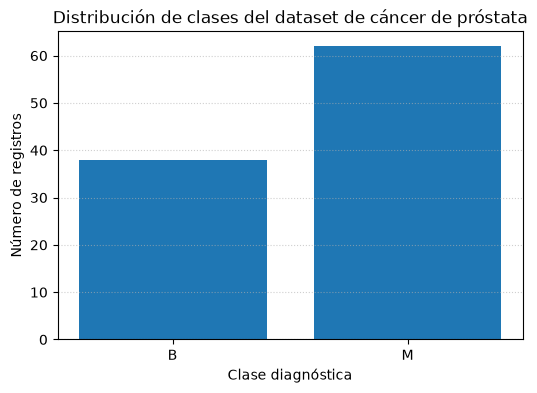

Gráfica guardada en: D:\DISCO C\Antonio Toro\UIA-MAI\6. Aprendizaje inteligente\Unidad2\practica_knn_cart_prostata\practica_knn_cart_prostata\outputs\graficas\distribucion_clases_dataset.png


In [6]:
# Gráfica de distribución de clases.

class_counts = df["diagnosis_result"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Distribución de clases del dataset de cáncer de próstata")
plt.xlabel("Clase diagnóstica")
plt.ylabel("Número de registros")
plt.grid(axis="y", linestyle=":", alpha=0.6)

output_path = OUTPUT_GRAPHS / "distribucion_clases_dataset.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Gráfica guardada en: {output_path}")


## 7. Preparación de los datos

La variable objetivo `diagnosis_result` se codifica numéricamente para que los modelos puedan procesarla. La clase `M` se considera la clase positiva porque representa el diagnóstico maligno.

El dataset se divide en entrenamiento y prueba. Además, se aplica estandarización para KNN porque este algoritmo depende de distancias y es sensible a la escala de las variables.


In [7]:
# Preparación de variables predictoras y variable objetivo.

FEATURE_COLUMNS = [
    "radius",
    "texture",
    "perimeter",
    "area",
    "smoothness",
    "compactness",
    "symmetry",
    "fractal_dimension",
]

X = df[FEATURE_COLUMNS].copy()
y_labels = df["diagnosis_result"].copy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Codificación de clases:", class_mapping)

# Asegurar que M sea la clase positiva para la curva ROC.
positive_class_encoded = class_mapping["M"]
print("Clase positiva para ROC: M =", positive_class_encoded)


Codificación de clases: {'B': np.int64(0), 'M': np.int64(1)}
Clase positiva para ROC: M = 1


In [8]:
# División entrenamiento/prueba y escalamiento para KNN.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba: {X_test.shape[0]} registros")


Entrenamiento: 80 registros
Prueba: 20 registros


## 8. Implementación de KNN y CART

Ambos modelos se entrenan sobre la misma partición de datos para garantizar una comparación justa. KNN utiliza variables estandarizadas, mientras que CART utiliza las variables originales, ya que los árboles de decisión no requieren escalamiento.


In [9]:
# Funciones de entrenamiento, evaluación y reporte.

def train_knn_model(X_train_scaled: np.ndarray, y_train: np.ndarray, n_neighbors: int = 5) -> KNeighborsClassifier:
    """Entrena un modelo KNN para clasificación binaria.

    KNN clasifica nuevas observaciones según la clase predominante entre
    sus vecinos más cercanos. En esta práctica se usa sobre variables
    estandarizadas porque el algoritmo depende de distancias.

    Args:
        X_train_scaled: Matriz de entrenamiento previamente estandarizada.
        y_train: Vector de etiquetas binarias de entrenamiento.
        n_neighbors: Número de vecinos considerados por el algoritmo.

    Returns:
        Modelo KNeighborsClassifier entrenado.

    Raises:
        ValueError: Si n_neighbors es menor que 1.
    """
    if n_neighbors < 1:
        raise ValueError("n_neighbors debe ser mayor o igual que 1.")

    model = KNeighborsClassifier(n_neighbors=n_neighbors)
    model.fit(X_train_scaled, y_train)
    logger.info("Modelo KNN entrenado con k=%s.", n_neighbors)
    return model


def train_cart_model(X_train: pd.DataFrame, y_train: np.ndarray, max_depth: int = 4) -> DecisionTreeClassifier:
    """Entrena un Árbol de Decisión CART para clasificación binaria.

    CART construye reglas jerárquicas de decisión y permite identificar
    variables relevantes mediante la importancia de características. Se
    limita la profundidad para reducir el riesgo de sobreajuste.

    Args:
        X_train: DataFrame con variables predictoras originales.
        y_train: Vector de etiquetas binarias de entrenamiento.
        max_depth: Profundidad máxima permitida del árbol.

    Returns:
        Modelo DecisionTreeClassifier entrenado.

    Raises:
        ValueError: Si max_depth es menor que 1.
    """
    if max_depth < 1:
        raise ValueError("max_depth debe ser mayor o igual que 1.")

    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=max_depth,
        random_state=42,
    )
    model.fit(X_train, y_train)
    logger.info("Modelo CART entrenado con max_depth=%s.", max_depth)
    return model


knn_model = train_knn_model(X_train_scaled, y_train, n_neighbors=5)
cart_model = train_cart_model(X_train, y_train, max_depth=4)

print("Modelos entrenados correctamente: KNN y CART.")


2026-06-30 15:52:48,112 | INFO | practica_knn_cart_prostata | Modelo KNN entrenado con k=5.
2026-06-30 15:52:48,118 | INFO | practica_knn_cart_prostata | Modelo CART entrenado con max_depth=4.


Modelos entrenados correctamente: KNN y CART.


## 9. Evaluación de los modelos

La evaluación se realiza sobre el conjunto de prueba. Para cada modelo se calculan métricas de clasificación y probabilidades de pertenencia a la clase positiva `M`, necesarias para construir la curva ROC.


In [10]:
# Predicciones y probabilidades.

y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_cart = cart_model.predict(X_test)

y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, positive_class_encoded]
y_prob_cart = cart_model.predict_proba(X_test)[:, positive_class_encoded]

print("Predicciones generadas para KNN y CART.")


Predicciones generadas para KNN y CART.


In [11]:
# Tabla comparativa de métricas.

def build_metrics_table(
    y_true: np.ndarray,
    y_pred_knn: np.ndarray,
    y_pred_cart: np.ndarray,
    y_prob_knn: np.ndarray,
    y_prob_cart: np.ndarray,
) -> pd.DataFrame:
    """Construye una tabla comparativa de métricas para KNN y CART.

    La tabla permite comparar ambos modelos bajo las mismas métricas:
    accuracy, precision, recall, F1-score y AUC. La clase positiva es
    el diagnóstico maligno.

    Args:
        y_true: Etiquetas reales del conjunto de prueba.
        y_pred_knn: Predicciones discretas del modelo KNN.
        y_pred_cart: Predicciones discretas del modelo CART.
        y_prob_knn: Probabilidades KNN para la clase positiva.
        y_prob_cart: Probabilidades CART para la clase positiva.

    Returns:
        DataFrame con una fila por modelo y columnas de métricas.
    """
    fpr_knn, tpr_knn, _ = roc_curve(y_true, y_prob_knn, pos_label=positive_class_encoded)
    fpr_cart, tpr_cart, _ = roc_curve(y_true, y_prob_cart, pos_label=positive_class_encoded)

    rows = [
        {
            "modelo": "KNN",
            "accuracy": accuracy_score(y_true, y_pred_knn),
            "precision": precision_score(y_true, y_pred_knn, pos_label=positive_class_encoded),
            "recall": recall_score(y_true, y_pred_knn, pos_label=positive_class_encoded),
            "f1_score": f1_score(y_true, y_pred_knn, pos_label=positive_class_encoded),
            "auc": auc(fpr_knn, tpr_knn),
        },
        {
            "modelo": "CART",
            "accuracy": accuracy_score(y_true, y_pred_cart),
            "precision": precision_score(y_true, y_pred_cart, pos_label=positive_class_encoded),
            "recall": recall_score(y_true, y_pred_cart, pos_label=positive_class_encoded),
            "f1_score": f1_score(y_true, y_pred_cart, pos_label=positive_class_encoded),
            "auc": auc(fpr_cart, tpr_cart),
        },
    ]
    return pd.DataFrame(rows)


metrics_df = build_metrics_table(y_test, y_pred_knn, y_pred_cart, y_prob_knn, y_prob_cart)
metrics_path = OUTPUT_TABLES / "metricas_comparativas_knn_cart.csv"
metrics_df.to_csv(metrics_path, index=False)

display_compact_dataframe(metrics_df.round(4), title="Métricas comparativas: KNN vs CART")
print(f"Tabla guardada en: {metrics_path}")


modelo,accuracy,precision,recall,f1_score,auc
KNN,0.85,0.8462,0.9167,0.8800,0.8542
CART,0.80,0.8333,0.8333,0.8333,0.8125


Tabla guardada en: D:\DISCO C\Antonio Toro\UIA-MAI\6. Aprendizaje inteligente\Unidad2\practica_knn_cart_prostata\practica_knn_cart_prostata\outputs\tablas\metricas_comparativas_knn_cart.csv


### 9.1 Matriz de confusión - KNN

La matriz de confusión del modelo KNN permite observar cuántos registros benignos y malignos fueron clasificados correctamente o incorrectamente por el algoritmo basado en vecinos cercanos.


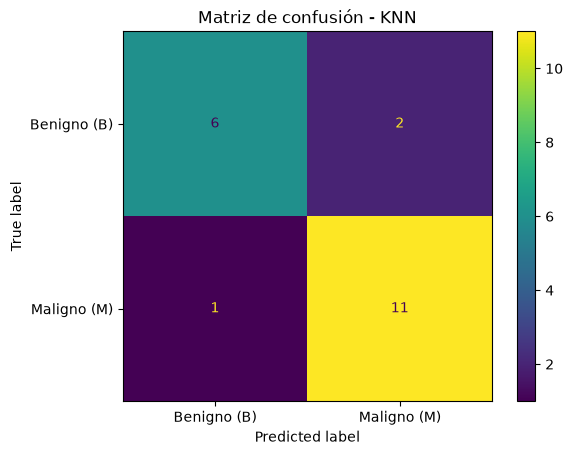

Gráfica guardada en: D:\DISCO C\Antonio Toro\UIA-MAI\6. Aprendizaje inteligente\Unidad2\practica_knn_cart_prostata\practica_knn_cart_prostata\outputs\graficas\matriz_confusion_knn.png

Reporte de clasificación - KNN:
              precision    recall  f1-score   support

 Benigno (B)       0.86      0.75      0.80         8
 Maligno (M)       0.85      0.92      0.88        12

    accuracy                           0.85        20
   macro avg       0.85      0.83      0.84        20
weighted avg       0.85      0.85      0.85        20



In [12]:
# Matriz de confusión - KNN.

cm_knn = confusion_matrix(y_test, y_pred_knn, labels=[class_mapping["B"], class_mapping["M"]])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["Benigno (B)", "Maligno (M)"],
)
disp.plot(values_format="d")
plt.title("Matriz de confusión - KNN")
plt.grid(False)

output_path = OUTPUT_GRAPHS / "matriz_confusion_knn.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Gráfica guardada en: {output_path}")
print("\nReporte de clasificación - KNN:")
print(classification_report(y_test, y_pred_knn, target_names=["Benigno (B)", "Maligno (M)"]))


### 9.2 Matriz de confusión - CART

La matriz de confusión del modelo CART permite observar el desempeño del árbol de decisión y comparar sus aciertos y errores con los obtenidos por KNN.


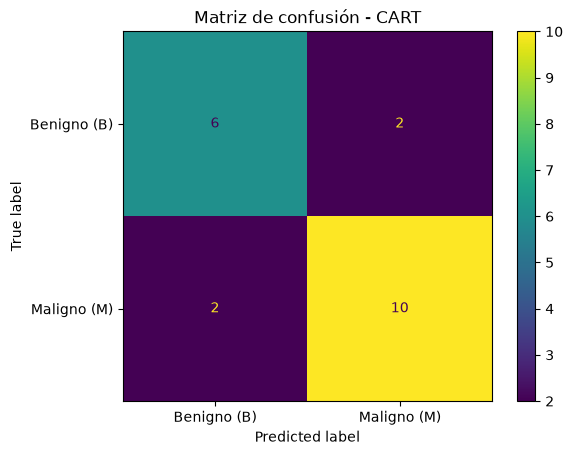

Gráfica guardada en: D:\DISCO C\Antonio Toro\UIA-MAI\6. Aprendizaje inteligente\Unidad2\practica_knn_cart_prostata\practica_knn_cart_prostata\outputs\graficas\matriz_confusion_cart.png

Reporte de clasificación - CART:
              precision    recall  f1-score   support

 Benigno (B)       0.75      0.75      0.75         8
 Maligno (M)       0.83      0.83      0.83        12

    accuracy                           0.80        20
   macro avg       0.79      0.79      0.79        20
weighted avg       0.80      0.80      0.80        20



In [13]:
# Matriz de confusión - CART.

cm_cart = confusion_matrix(y_test, y_pred_cart, labels=[class_mapping["B"], class_mapping["M"]])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cart,
    display_labels=["Benigno (B)", "Maligno (M)"],
)
disp.plot(values_format="d")
plt.title("Matriz de confusión - CART")
plt.grid(False)

output_path = OUTPUT_GRAPHS / "matriz_confusion_cart.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Gráfica guardada en: {output_path}")
print("\nReporte de clasificación - CART:")
print(classification_report(y_test, y_pred_cart, target_names=["Benigno (B)", "Maligno (M)"]))


### 9.3 Importancia de variables - CART

CART permite identificar la contribución relativa de cada variable predictora. Esta gráfica corresponde únicamente al modelo CART, no a KNN.


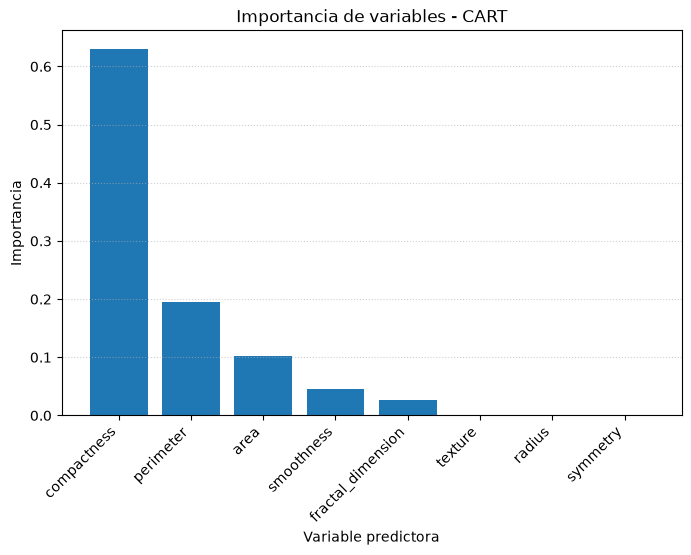

variable,importancia
compactness,0.6304
perimeter,0.1957
area,0.1023
smoothness,0.0448
fractal_dimension,0.0268
texture,0.0000
radius,0.0000
symmetry,0.0000


Tabla guardada en: D:\DISCO C\Antonio Toro\UIA-MAI\6. Aprendizaje inteligente\Unidad2\practica_knn_cart_prostata\practica_knn_cart_prostata\outputs\tablas\importancia_variables_cart.csv
Gráfica guardada en: D:\DISCO C\Antonio Toro\UIA-MAI\6. Aprendizaje inteligente\Unidad2\practica_knn_cart_prostata\practica_knn_cart_prostata\outputs\graficas\importancia_variables_cart.png


In [14]:
# Importancia de variables - CART.

importance_df = pd.DataFrame({
    "variable": FEATURE_COLUMNS,
    "importancia": cart_model.feature_importances_,
}).sort_values("importancia", ascending=False)

importance_path = OUTPUT_TABLES / "importancia_variables_cart.csv"
importance_df.to_csv(importance_path, index=False)

plt.figure(figsize=(8, 5))
plt.bar(importance_df["variable"], importance_df["importancia"])
plt.title("Importancia de variables - CART")
plt.xlabel("Variable predictora")
plt.ylabel("Importancia")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle=":", alpha=0.6)

output_path = OUTPUT_GRAPHS / "importancia_variables_cart.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

display_compact_dataframe(importance_df.round(4), title="Importancia de variables calculada por CART")
print(f"Tabla guardada en: {importance_path}")
print(f"Gráfica guardada en: {output_path}")


### 9.4 Visualización del árbol CART con sus nodos

Además de la importancia de variables, CART permite visualizar la estructura completa del árbol de decisión. Este gráfico muestra los nodos, reglas de partición, impureza Gini, número de muestras y clase estimada en cada hoja. Esta evidencia corresponde únicamente al modelo CART y aporta interpretabilidad al análisis.

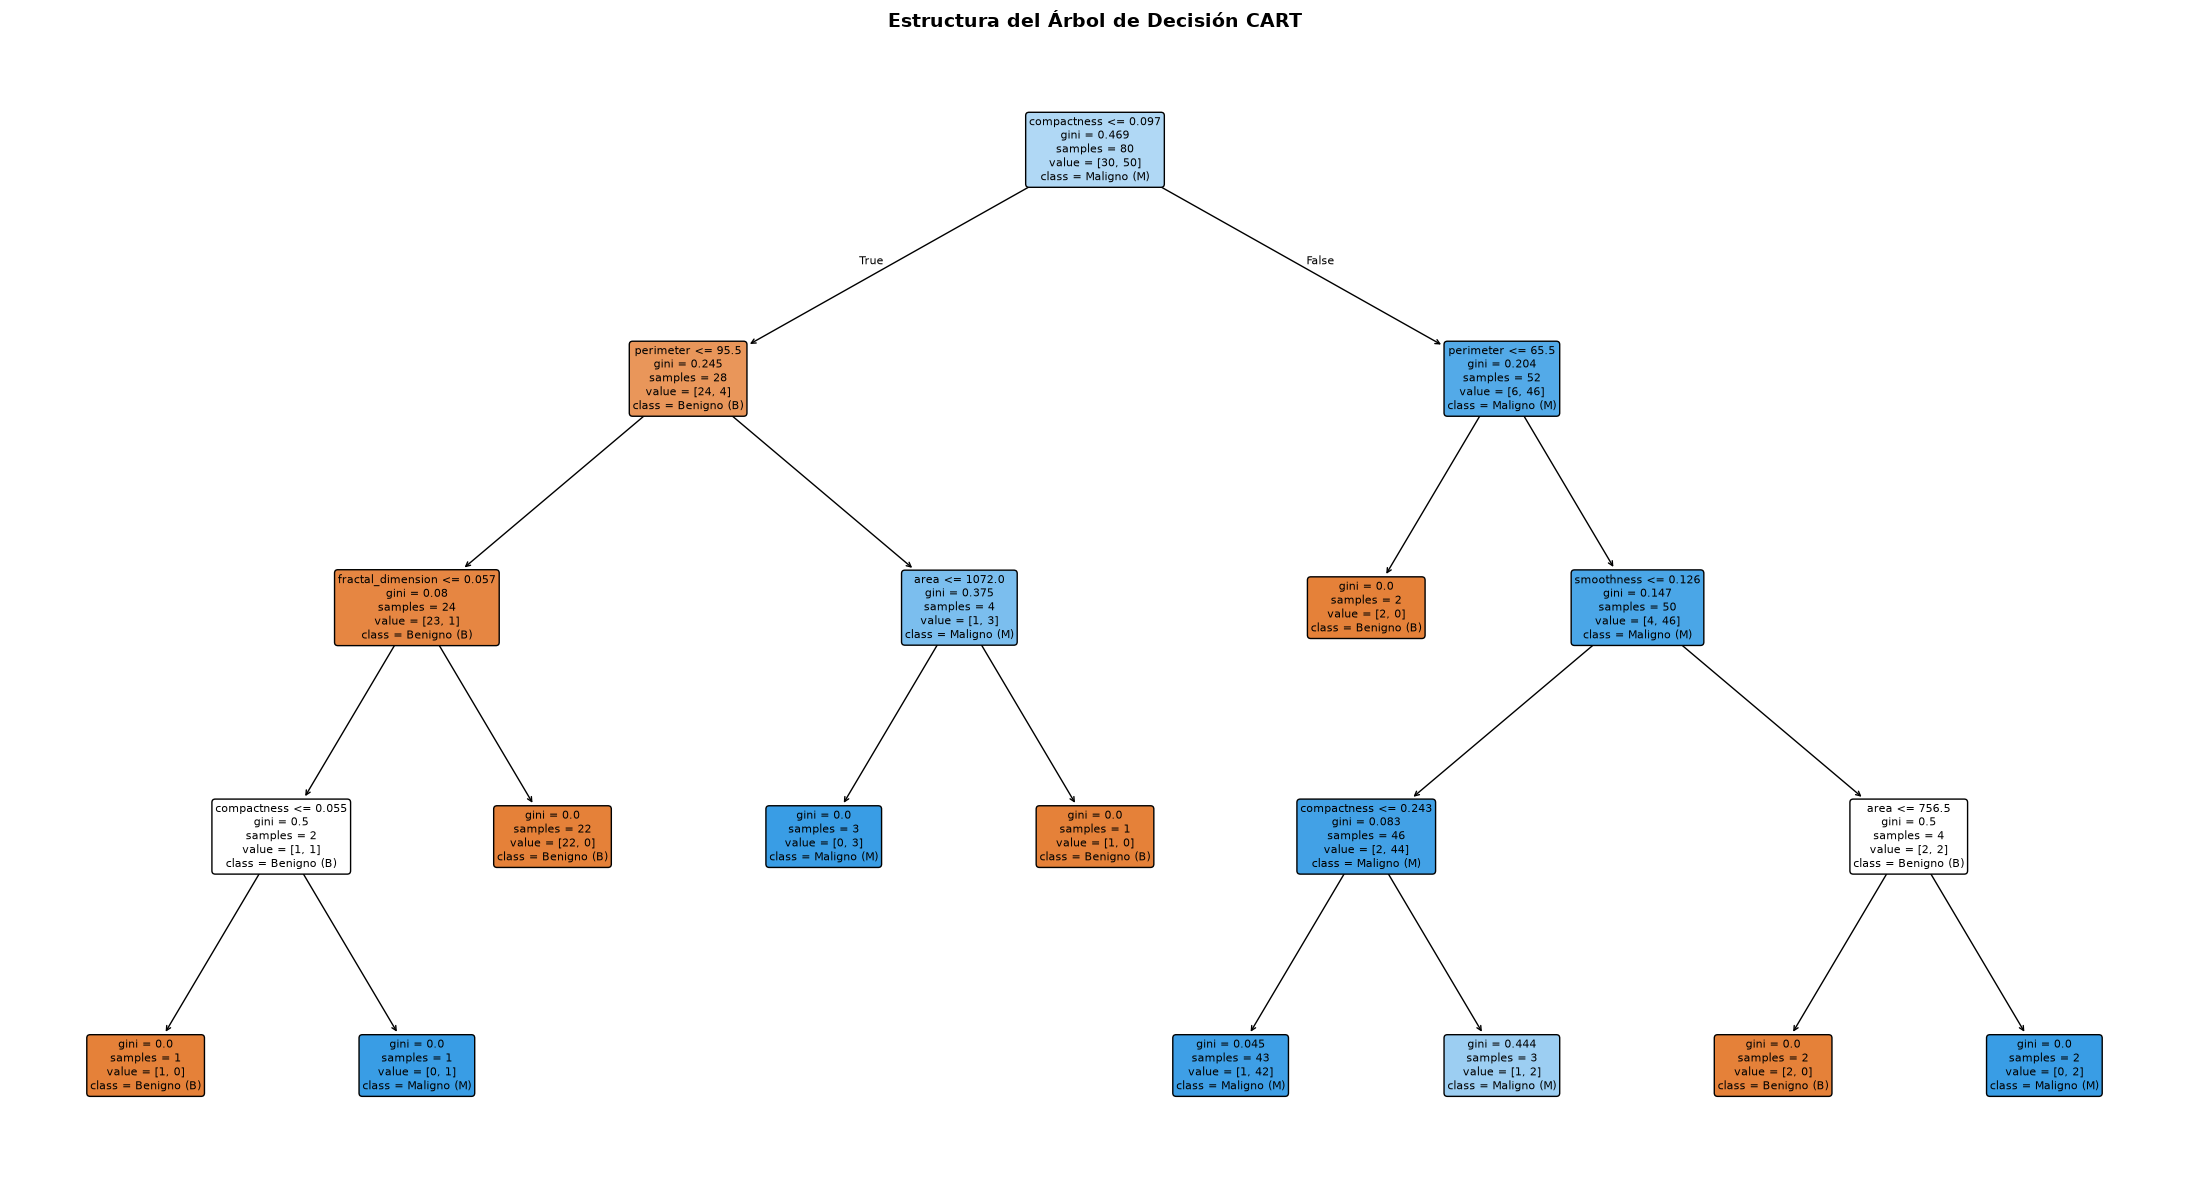

Árbol CART guardado en: D:\DISCO C\Antonio Toro\UIA-MAI\6. Aprendizaje inteligente\Unidad2\practica_knn_cart_prostata\practica_knn_cart_prostata\outputs\graficas\arbol_cart_nodos.png


In [15]:
# Visualización del árbol CART con sus nodos.

def plot_cart_tree(
    cart_model: DecisionTreeClassifier,
    feature_names: list[str],
    class_names: list[str],
    output_path: Path,
) -> None:
    """Genera y guarda la visualización completa del árbol CART.

    Esta función permite inspeccionar la estructura interna del modelo CART
    entrenado. El gráfico muestra las reglas de decisión usadas en cada nodo,
    la impureza Gini, el número de muestras disponibles y la clase estimada
    en las hojas terminales. Su propósito dentro de la práctica es reforzar
    la interpretabilidad del modelo de árbol de decisión.

    Args:
        cart_model: Modelo DecisionTreeClassifier previamente entrenado.
        feature_names: Lista con los nombres de las variables predictoras.
        class_names: Lista con los nombres descriptivos de las clases.
        output_path: Ruta de salida donde se guardará la imagen PNG.

    Returns:
        None. La función guarda la figura en disco y la muestra en pantalla.

    Raises:
        ValueError: Si el modelo CART no está entrenado o si las listas de
            variables/clases están vacías.
    """
    if not hasattr(cart_model, "tree_"):
        raise ValueError("El modelo CART debe estar entrenado antes de graficarse.")
    if not feature_names:
        raise ValueError("La lista feature_names no puede estar vacía.")
    if not class_names:
        raise ValueError("La lista class_names no puede estar vacía.")

    plt.figure(figsize=(22, 12))
    plot_tree(
        cart_model,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        impurity=True,
        proportion=False,
        fontsize=8,
    )
    plt.title("Estructura del Árbol de Decisión CART", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


cart_tree_path = OUTPUT_GRAPHS / "arbol_cart_nodos.png"

plot_cart_tree(
    cart_model=cart_model,
    feature_names=FEATURE_COLUMNS,
    class_names=["Benigno (B)", "Maligno (M)"],
    output_path=cart_tree_path,
)

print(f"Árbol CART guardado en: {cart_tree_path}")

### 9.5 Curva ROC comparativa: KNN vs CART

La curva ROC compara la capacidad discriminativa de ambos modelos usando diferentes umbrales de decisión. Esta es la gráfica central de la práctica, porque permite evaluar simultáneamente KNN y CART bajo la misma métrica visual.


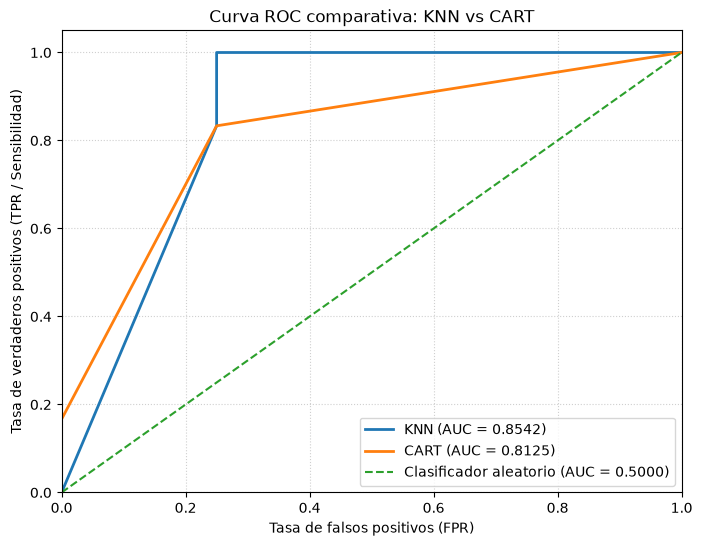

AUC KNN: 0.8542
AUC CART: 0.8125
Gráfica guardada en: D:\DISCO C\Antonio Toro\UIA-MAI\6. Aprendizaje inteligente\Unidad2\practica_knn_cart_prostata\practica_knn_cart_prostata\outputs\graficas\curva_roc_knn_cart.png


In [16]:
# Curva ROC comparativa: KNN vs CART.

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn, pos_label=positive_class_encoded)
fpr_cart, tpr_cart, _ = roc_curve(y_test, y_prob_cart, pos_label=positive_class_encoded)

auc_knn = auc(fpr_knn, tpr_knn)
auc_cart = auc(fpr_cart, tpr_cart)

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, linewidth=2, label=f"KNN (AUC = {auc_knn:.4f})")
plt.plot(fpr_cart, tpr_cart, linewidth=2, label=f"CART (AUC = {auc_cart:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Clasificador aleatorio (AUC = 0.5000)")

plt.title("Curva ROC comparativa: KNN vs CART")
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR / Sensibilidad)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.6)

output_path = OUTPUT_GRAPHS / "curva_roc_knn_cart.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"AUC KNN: {auc_knn:.4f}")
print(f"AUC CART: {auc_cart:.4f}")
print(f"Gráfica guardada en: {output_path}")


## 10. Interpretación de resultados

La comparación se realiza sobre el mismo conjunto de prueba. **KNN** evalúa la similitud geométrica entre registros, mientras que **CART** genera reglas jerárquicas, importancia de variables y una estructura visual de nodos que facilita interpretar el proceso de decisión.

La curva ROC permite comparar ambos modelos sin depender de un único umbral de decisión. El resultado más relevante es que **KNN obtuvo el mayor AUC (0.8542)** frente a **CART (0.8125)**, por lo que presentó mejor capacidad global para discriminar entre diagnósticos benignos y malignos.

Además, **KNN alcanzó un recall de 0.9167**, superior al de **CART (0.8333)**, lo que indica mayor sensibilidad para identificar correctamente la clase positiva. Sin embargo, **CART conserva una ventaja interpretativa**, ya que permite observar las reglas de decisión, los nodos del árbol y la importancia relativa de las variables.

En el modelo **CART**, las variables predictoras más relevantes fueron **compactness**, **perimeter** y **area**. Esto indica que el árbol basó gran parte de sus decisiones en características morfológicas relacionadas con la **compacidad**, el **tamaño** y la **extensión geométrica** de la muestra. En términos interpretativos, estas variables ayudan a explicar por qué determinados registros fueron clasificados como benignos o malignos, ya que el modelo no solo produce una predicción, sino también una secuencia de condiciones que puede revisarse visualmente en los nodos del árbol.

En conjunto, **KNN fue el modelo con mejor rendimiento predictivo**, mientras que **CART fue el modelo más explicativo**. Por tanto, ambos modelos aportan valor complementario: **KNN por desempeño** y **CART por interpretabilidad**.


In [17]:
# Comentario automático breve según AUC.

best_model = "KNN" if auc_knn > auc_cart else "CART" if auc_cart > auc_knn else "empate entre KNN y CART"

print("Resumen comparativo:")
print(metrics_df.round(4).to_string(index=False))
print(f"\nSegún AUC, el mejor desempeño global corresponde a: {best_model}.")


Resumen comparativo:
modelo  accuracy  precision  recall  f1_score    auc
   KNN      0.85     0.8462  0.9167    0.8800 0.8542
  CART      0.80     0.8333  0.8333    0.8333 0.8125

Según AUC, el mejor desempeño global corresponde a: KNN.


## 11. Conclusiones

1. La práctica permitió implementar, evaluar y comparar dos algoritmos de aprendizaje supervisado, **KNN y CART**, sobre un mismo problema de clasificación binaria para el diagnóstico de cáncer de próstata.

2. **KNN** fue el modelo con mejor rendimiento predictivo, al obtener un **AUC de 0.8542** y un **recall de 0.9167**, lo que evidencia mayor capacidad para discriminar entre diagnósticos benignos y malignos.

3. **CART** presentó un desempeño competitivo (**AUC = 0.8125**) y aportó mayor interpretabilidad mediante reglas jerárquicas, visualización de nodos e importancia de variables, destacando predictores como **compactness**, **perimeter** y **area**.

4. La **curva ROC** y el **AUC** permitieron comparar ambos modelos más allá de una predicción binaria fija, confirmando que **KNN fue superior en capacidad predictiva**, mientras que **CART destacó por su capacidad explicativa**.

5. El dataset de cáncer de próstata resultó adecuado porque contiene variables morfológicas numéricas y una clase objetivo binaria, lo que permitió aplicar KNN, CART y evaluación ROC bajo las mismas condiciones experimentales.


## 12. Referencias

Ababneh, J. (2019). *Application of Naïve Bayes, Decision Tree, and K-Nearest Neighbors for Automated Text Classification*. Modern Applied Science, 13(11), 31–36. https://doi.org/10.5539/mas.v13n11p31

Gironés Roig, J., Casas Roma, J., Minguillón Alfonso, J., & Caihuelas Quiles, R. (2017). *Minería de datos: modelos y algoritmos*. Editorial UOC.

Hastie, T., Tibshirani, R., & Friedman, J. (2017). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction* (2nd ed.). Springer.

Jadhav, S. D., & Channe, H. P. (2016). Comparative Study of K-NN, Naive Bayes and Decision Tree Classification Techniques. *International Journal of Science and Research, 5*(1), 1842–1845. 
https://www.academia.edu/95275199/

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., VanderPlas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html

Saifi, S. (2018). *Prostate Cancer Dataset*. Kaggle. https://www.kaggle.com/datasets/sajidsaifi/prostate-cancer

